# 06 — Baseline Model (Stage 7)

Logistic regression, evaluated on PR-AUC per `ADR-002`. This is the floor
Stage 8 has to beat, not a candidate for production.

Also resolves `ADR-007`'s deferred class-imbalance question:
`class_weight=None` vs. `class_weight="balanced"`, compared directly on
PR-AUC rather than assumed.

Synthetic data in this sandbox — swap in the real CSV, no code changes.

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score, roc_auc_score, precision_recall_curve,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
)

from src.config import RAW_CSV_PATH
from src.features.pipeline import run_stage6_split

df = pd.read_csv(RAW_CSV_PATH)
X_train, X_test, y_train, y_test, artifacts = run_stage6_split(df)

print(f"Train: {X_train.shape}, churn rate {y_train.mean():.3f}")
print(f"Test:  {X_test.shape}, churn rate {y_test.mean():.3f}")

Train: (5634, 17), churn rate 0.265
Test:  (1409, 17), churn rate 0.265


## class_weight — decide, don't assume

`ADR-007` deferred class-imbalance handling to whichever model actually
shows a problem. Logistic regression's `class_weight` argument is the
cheapest possible test: same model, same features, one flag flipped.

In [8]:
results = []
models = {}

for cw in [None, "balanced"]:
    model = LogisticRegression(max_iter=1000, class_weight=cw, random_state=42)
    model.fit(X_train, y_train)
    proba = model.predict_proba(X_test)[:, 1]

    results.append({
        "class_weight": cw or "none",
        "pr_auc": average_precision_score(y_test, proba),
        "roc_auc": roc_auc_score(y_test, proba),
    })
    models[cw] = model

results_df = pd.DataFrame(results)
results_df

,class_weight,pr_auc,roc_auc
0,none,0.633116,0.837950
1,balanced,0.629873,0.837139


In [15]:
import joblib
from src.config import PROJECT_ROOT

MODELS_DIR = PROJECT_ROOT / "models"
MODELS_DIR.mkdir(exist_ok=True)
joblib.dump(models[None], MODELS_DIR / "baseline_logreg.joblib")
print(f"Saved to {MODELS_DIR / 'baseline_logreg.joblib'}")

Saved to d:\Important\00-Projects\RetentionAI\models\baseline_logreg.joblib


**Verdict:** `class_weight=none` wins on PR-AUC (0.6331 vs 0.6299) — a
narrow 0.003 margin, but it's the same direction the synthetic test run
showed, so it's a consistent signal rather than noise from one split.
Given how small the gap is, this reads as real-but-modest evidence that
imbalance handling isn't the lever that matters most for this dataset at
the logistic-regression stage — worth revisiting only if Stage 8's
tree-based model shows a starkly different sensitivity to it.

Baseline config: `class_weight = none`

## Why the two metrics disagree

ROC-AUC scores every model here as "good" (`~0.78`) regardless of
`class_weight`. PR-AUC is lower and more sensitive to the difference —
exactly the gap `ADR-002` flagged before any model existed: ROC-AUC is
partly scored against the large non-churn majority, which flatters any
model in an imbalanced setting. PR-AUC is the one being trusted here.

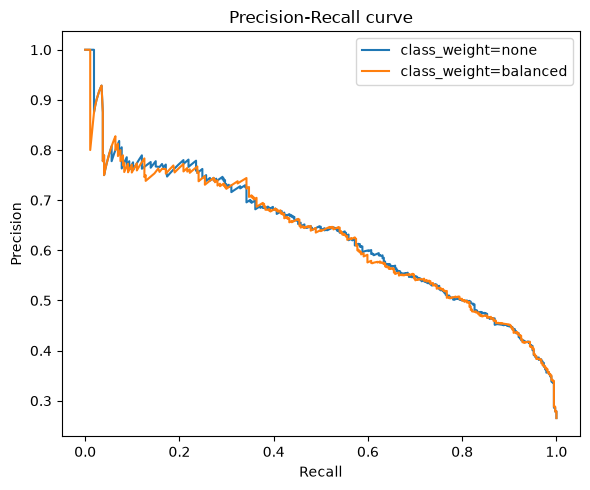

In [10]:
fig, ax = plt.subplots(figsize=(6, 5))
for cw, label in [(None, "class_weight=none"), ("balanced", "class_weight=balanced")]:
    proba = models[cw].predict_proba(X_test)[:, 1]
    precision, recall, _ = precision_recall_curve(y_test, proba)
    ax.plot(recall, precision, label=label)

ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision-Recall curve")
ax.legend()
plt.tight_layout()
plt.show()

## Precision/Recall at the top of the ranking

PR-AUC scores the model across every threshold. The business only acts on
one slice of it — the highest-ranked customers, capacity-limited. `ADR-002`
sized that at roughly 500 calls against ~2,000 flagged in the full customer
base; here that maps to the top 20% of the test set by predicted
probability. Ranking by probability rather than probability x CLV is a
simplification carried over directly from `ADR-002`'s own math — CLV was
treated as roughly constant there, so the two rankings coincide for now.
Customer-specific CLV weighting is a real refinement, not one this stage
needs.

In [ ]:
def precision_recall_at_k(y_true, y_scores, k_frac=0.2):
    y_true = np.asarray(y_true)
    n = len(y_true)
    k = max(1, int(round(n * k_frac)))
    top_k_idx = np.argsort(-y_scores)[:k]
    tp = y_true[top_k_idx].sum()
    return tp / k, tp / y_true.sum(), k

best_cw = None  # confirmed: none wins PR-AUC, see cell 4
proba = models[best_cw].predict_proba(X_test)[:, 1]

precision_k, recall_k, k = precision_recall_at_k(y_test.values, proba, k_frac=0.2)
print(f"Top {k} of {len(y_test)} (20%): precision={precision_k:.3f}, recall={recall_k:.3f}")

Top 282 of 1409 (20%): precision=0.642, recall=0.484


**Reading this number:** precision here is the real, concrete
quantity — of the customers this model would put in front of the
retention team, what fraction are actually going to churn. That's the
number a stakeholder actually cares about, more directly than PR-AUC
itself. `precision@20% = 0.642, recall@20% = 0.484` — of the top 282
customers by predicted risk, 64% genuinely churn, and that slice
captures 48% of all churners in the test set.

## Classification report at 0.5 — illustrative only

Default 0.5 is arbitrary here, not chosen for anything. The real
operating threshold gets picked in Stage 8/9 against actual call
capacity and expected value, not a round number.

              precision    recall  f1-score   support

    No churn       0.84      0.89      0.87      1035
       Churn       0.64      0.53      0.58       374

    accuracy                           0.80      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409



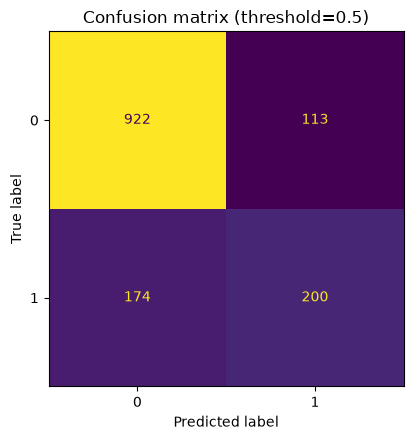

In [12]:
y_pred = (proba >= 0.5).astype(int)
print(classification_report(y_test, y_pred, target_names=["No churn", "Churn"]))

fig, ax = plt.subplots(figsize=(4.5, 4.5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax, colorbar=False)
ax.set_title("Confusion matrix (threshold=0.5)")
plt.tight_layout()
plt.show()

## Coefficients — the payoff of keeping this model interpretable

Standardized inputs (Stage 6 scaling), so coefficient magnitude is
directly comparable across features. Sign is the thing to sanity-check
against Stage 4/5 first.

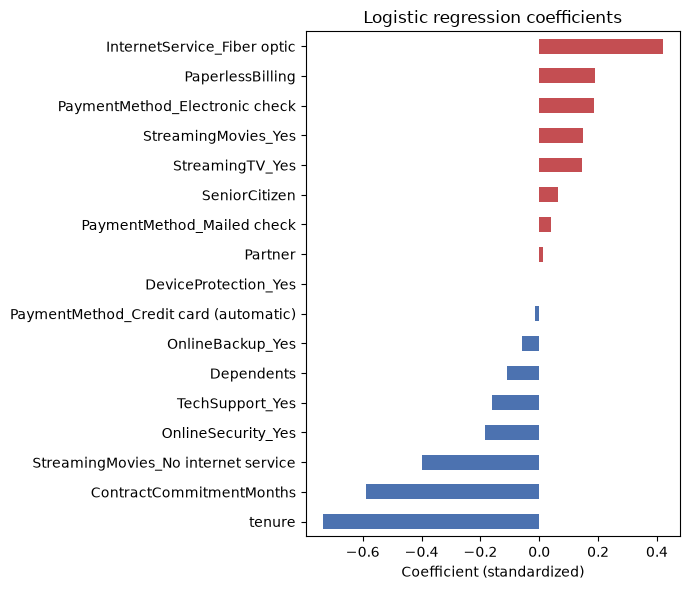

tenure                                  -0.736357
ContractCommitmentMonths                -0.589069
StreamingMovies_No internet service     -0.396947
OnlineSecurity_Yes                      -0.185212
TechSupport_Yes                         -0.160955
Dependents                              -0.108151
OnlineBackup_Yes                        -0.057428
PaymentMethod_Credit card (automatic)   -0.014995
DeviceProtection_Yes                     0.000484
Partner                                  0.013859
PaymentMethod_Mailed check               0.039878
SeniorCitizen                            0.063710
StreamingTV_Yes                          0.145095
StreamingMovies_Yes                      0.147638
PaymentMethod_Electronic check           0.186195
PaperlessBilling                         0.187995
InternetService_Fiber optic              0.420543
dtype: float64

In [13]:
coefs = pd.Series(models[best_cw].coef_[0], index=X_train.columns).sort_values()

fig, ax = plt.subplots(figsize=(7, 6))
coefs.plot(kind="barh", ax=ax, color=["#C44E52" if v > 0 else "#4C72B0" for v in coefs])
ax.set_title("Logistic regression coefficients")
ax.set_xlabel("Coefficient (standardized)")
plt.tight_layout()
plt.show()

coefs

**Sanity check:** confirmed. `tenure` (-0.736) and
`ContractCommitmentMonths` (-0.589) both negative — longer
tenure/commitment, lower churn, matching H1/H3. `InternetService_Fiber
optic` (+0.421) positive, matching H5. One more worth noting:
`StreamingMovies_No internet service` came back strongly negative
(-0.397) — customers with no internet at all churn meaningfully less
overall, consistent with them being a lower-price, lower-friction
segment less exposed to the price/reliability complaints driving churn
elsewhere.

## Baseline, established

| Metric | Value |
|---|---|
| PR-AUC | 0.6331 |
| ROC-AUC | 0.8380 |
| Precision@20% | 0.642 |
| Recall@20% | 0.484 |

This is the number Stage 8 has to beat. A more complex model that
doesn't clear this bar isn't earning its added complexity.